# Mental Rotation 3D Objaverse Environment Demo

This notebook demonstrates the Mental Rotation 3D Objaverse environment with realistic 3D objects.

In [1]:
import os
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["MUJOCO_GL"] = "egl"
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy)

In [2]:
env = gym.make("mental_rotation_3d_objaverse/easy", seed=42)
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names()}")

Using GPU 3
Using GPU 7
Action Space: FuncConditional(['rotate', 'stop'])
Available actions: ['rotate', 'stop']


## 2. Reset and View Initial State

Observation shape: (128, 256, 3)
Info: {}


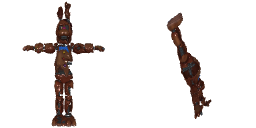


Task: Rotate the 3D object to match the target view

Task Prompt:
You are solving a 3D mental rotation task. Two panels are shown:
- Left: the target view of the object (identity orientation).
- Right: the current view that you can rotate.
Your job is to rotate the object on the right so it matches the left.

Available actions:
1. 'rotate': Apply an incremental Euler rotation (yaw, pitch, roll). Format: `('rotate', [d_roll, d_yaw, d_pitch])` with angles in degrees.
2. 'stop': Submit your final orientation. Format: `('stop', 'stop')`

Success: You succeed if the final rotation error is less than or equal to 15.0°.

Note: Rotations are applied in the object's local (intrinsic) axes

For example:
- Roll by 15°: `('rotate', [15, 0, 0])`
- To submit: `('stop', 'stop')`


In [3]:
obs, info = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Info: {info}")

display(Image.fromarray(obs))
print(f"\nTask: Rotate the 3D object to match the target view")
print(f"\nTask Prompt:\n{env.get_prompt()}")

## 3. Test Manual Actions

Action: ('rotate', [10.0, 20.0, 5.0])
Feedback: Action executed successfully.


user/launch/current/gymnasium/spaces/box.py:423: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


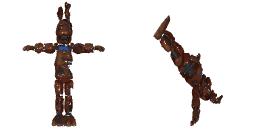

In [4]:
# Rotate the object
action = "('rotate', [10.0, 20.0, 5.0])"
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action: {action}")
print(f"Feedback: {info.get('env_feedback', 'N/A')}")
display(Image.fromarray(obs))

## 4. Test Solver

	err = EGL_NOT_INITIALIZED,
	baseOperation = eglMakeCurrent,
	cArguments = (
	),
	result = 0
)
Initial view:


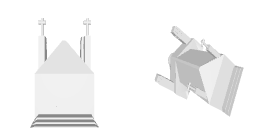


Solver generated 2 actions

Step 1: ('rotate', [-5.8, -32.5, 66.0])


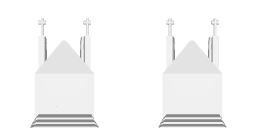


Step 2: ('stop', 'stop')


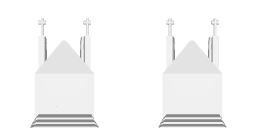


✓ Rotation complete! Reward: 1.0


In [5]:
env = gym.make("mental_rotation_3d_objaverse/easy", seed=100)
obs, info = env.reset()
print("Initial view:")
display(Image.fromarray(obs))

# Get solver actions
actions = env.solve()
print(f"\nSolver generated {len(actions)} actions")

# Execute solver actions
for i, action in enumerate(actions):
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"\nStep {i+1}: {action}")
    display(Image.fromarray(obs))
    if terminated:
        print(f"\n✓ Rotation complete! Reward: {reward}")
        break

env.close()

## 5. Test Hard Difficulty (Stricter Tolerance)

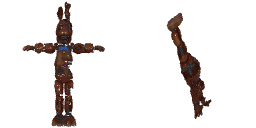


Solution: 2 actions
Reward: 1.0


user/launch/current/gymnasium/spaces/box.py:423: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


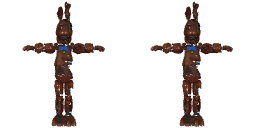

In [8]:
env_hard = gym.make("mental_rotation_3d_objaverse/hard", seed=42)
obs, info = env_hard.reset()
display(Image.fromarray(obs))

# Get solution
actions = env_hard.solve()
print(f"\nSolution: {len(actions)} actions")
for action in actions:
    obs, reward, terminated, truncated, info = env_hard.step(action)
    if terminated:
        print(f"Reward: {reward}")
        display(Image.fromarray(obs))
        break

env_hard.close()